In [34]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
! pip install tensorflow
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')



In [2]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [15]:
data=pd.read_csv("/content/Rent.csv")

In [16]:
data.head()

,BHK,Rent,Size,Floor,Area Locality,City,Bathroom,N_11,N_12,N_13,N_14,N_15,N_16,N_17,N_18,N_19,N_20,N_21,N_22
0,2,10000.0,1100.000000,454,220,4,2.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
1,2,20000.0,967.936049,14,1525,4,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,2,17000.0,1000.000000,14,1758,4,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,2,10000.0,967.936049,10,525,4,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
4,2,7500.0,850.000000,10,1888,4,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0


In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4727 entries, 0 to 4726
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   BHK            4727 non-null   int64  
 1   Rent           4727 non-null   float64
 2   Size           4727 non-null   float64
 3   Floor          4727 non-null   int64  
 4   Area Locality  4727 non-null   int64  
 5   City           4727 non-null   int64  
 6   Bathroom       4727 non-null   float64
 7   N_11           4727 non-null   float64
 8   N_12           4727 non-null   float64
 9   N_13           4727 non-null   float64
 10  N_14           4727 non-null   float64
 11  N_15           4727 non-null   float64
 12  N_16           4727 non-null   float64
 13  N_17           4727 non-null   float64
 14  N_18           4727 non-null   float64
 15  N_19           4727 non-null   float64
 16  N_20           4727 non-null   float64
 17  N_21           4727 non-null   float64
 18  N_22    

In [18]:
data.describe()

,BHK,Rent,Size,Floor,Area Locality,City,Bathroom,N_11,N_12,N_13,N_14,N_15,N_16,N_17,N_18,N_19,N_20,N_21,N_22
count,4727.000000,4727.000000,4727.000000,4727.000000,4727.000000,4727.000000,4727.000000,4727.000000,4727.000000,4727.000000,4727.000000,4727.000000,4727.000000,4727.000000,4727.000000,4727.000000,4727.000000,4727.000000,4727.000000
mean,2.082082,33828.690501,962.158582,228.930823,1090.191876,2.454411,1.962132,0.000423,0.482124,0.517453,0.143431,0.473873,0.382695,0.174529,0.725830,0.099640,0.320711,0.000212,0.679078
std,0.829032,56952.969970,608.358826,162.343589,632.789286,1.787477,0.872806,0.020567,0.499733,0.499748,0.350549,0.499370,0.486096,0.379604,0.446142,0.299552,0.466799,0.014545,0.466880
min,1.000000,1200.000000,10.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,10000.000000,552.500000,26.000000,550.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,16000.000000,850.000000,200.000000,1095.000000,2.000000,2.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
75%,3.000000,32250.000000,1200.000000,370.000000,1629.500000,4.000000,2.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
max,6.000000,1000000.000000,4800.000000,478.000000,2232.000000,5.000000,7.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [19]:
# Preprocessing
data= data.dropna()
data= pd.get_dummies(data,drop_first=True)

In [22]:
# Features & target
x=data.drop("Rent",axis=1)
y=data["Rent"]

In [24]:
# Split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [28]:
# Scaling
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [29]:
# Model
model=Sequential([
    Dense(32,activation="relu",input_shape=(x_train.shape[1],)),
    Dense(16,activation="relu"),
    Dense(1,activation="linear")
])


In [30]:
# Compile
model.compile(optimizer="adam",loss="mean_squared_error",metrics=["mae"])

In [31]:
# Train
history=model.fit(x_train,y_train,epochs=30,batch_size=32,validation_split=0.2)

Epoch 1/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 4628128256.0000 - mae: 33826.6445 - val_loss: 3893689344.0000 - val_mae: 34256.0625
Epoch 2/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4627282432.0000 - mae: 33820.4453 - val_loss: 3892215040.0000 - val_mae: 34245.6367
Epoch 3/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4624276480.0000 - mae: 33800.9297 - val_loss: 3887817216.0000 - val_mae: 34216.8516
Epoch 4/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4616896000.0000 - mae: 33756.5039 - val_loss: 3878362880.0000 - val_mae: 34156.9805
Epoch 5/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4603055104.0000 - mae: 33674.4727 - val_loss: 3862459392.0000 - val_mae: 34057.4570
Epoch 6/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4580857856.0000 - mae: 33542.5547 - val_loss: 3837683968.0000 - val_mae: 33902.9531
Epoch 7/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4549764096.0000 - mae: 33353.1016 - val_loss: 3804981248.0000 - val_mae: 33697.5547
Epoch 

In [32]:
# Predict
predictions=model.predict(x_test)

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [33]:
# Evaluate
loss, mae= model.evaluate(x_test,y_test)
print("Rent Model-> loss(MSE):",loss)
print("Rent Model-> MAE:",mae)

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1684978816.0000 - mae: 20487.6230
Rent Model-> loss(MSE): 1684978816.0
Rent Model-> MAE: 20487.623046875


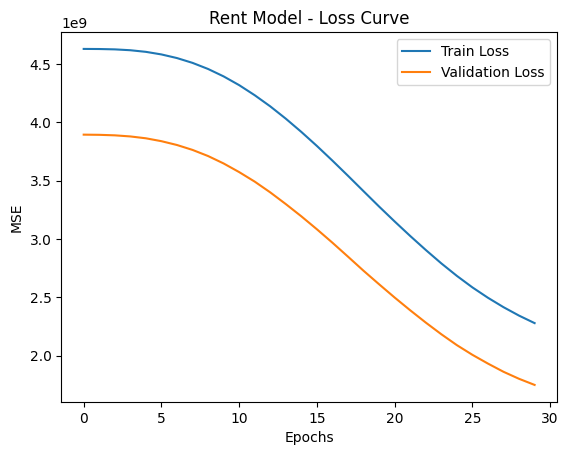

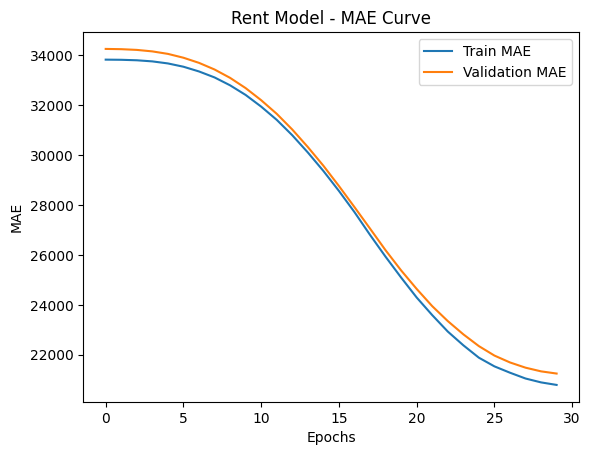

In [35]:
# Plot Loss (MSE)
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Rent Model - Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.show()

# Plot MAE
plt.figure()
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.legend()
plt.title('Rent Model - MAE Curve')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.show()

In [36]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, predictions)
print("R2 Score:", r2)

R2 Score: 0.41707753054768515


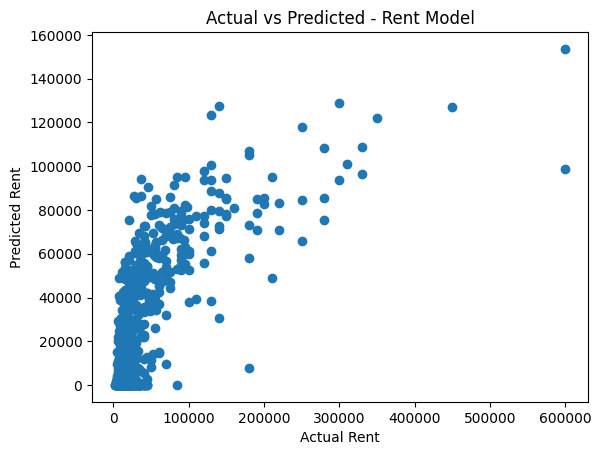

In [38]:
# Actual vs Predicted
plt.figure()
plt.scatter(y_test, predictions)
plt.xlabel('Actual Rent')
plt.ylabel('Predicted Rent')
plt.title('Actual vs Predicted - Rent Model')

plt.show()

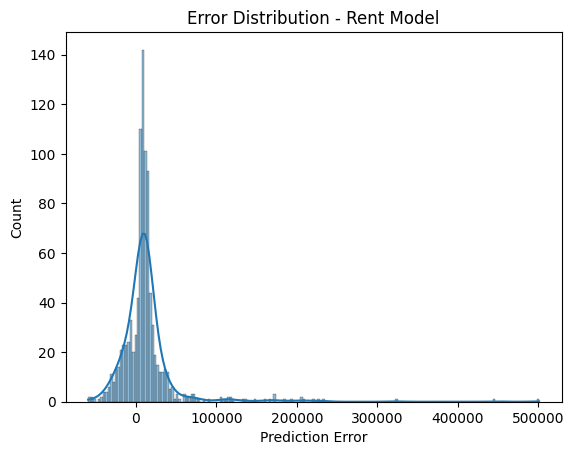

In [39]:
# Error Distribution
errors = y_test - predictions.flatten()

plt.figure()
sns.histplot(errors, kde=True)

plt.title('Error Distribution - Rent Model')
plt.xlabel('Prediction Error')

plt.show()